# Hydro-to-PHS Retrofit – Results Analysis

Analysis of the solved network from `results/retrofit-test/networks/base_s_3_elec_.nc`.

**Key questions:**
1. Were the retrofit storage units created correctly?
2. Did the optimizer choose to retrofit (z=1)?
3. Are the capacity conservation constraints satisfied?
4. What does the optimized dispatch look like?
5. Are the natural inflow profiles unique per bus, or country-level averages?
6. Does the hourly operation at each bus make physical sense?

In [51]:
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

#n = pypsa.Network(r"../pypsa-eur/results/retrofit-test_high CAPEX/networks/base_s_3_elec_.nc")
# n = pypsa.Network(r"../pypsa-eur/results/retrofit-test/networks/base_s_3_elec_.nc")
# n = pypsa.Network(r"../pypsa-eur/results/retrofit_FR_10_3h_myopic_25_30_35/networks/base_s_10_elec_.nc")  
n = pypsa.Network(r"../pypsa-eur/results/FR_10_3h_myopic_25_30_35/networks/base_s_10_elec_.nc")
print(f"Snapshots: {n.snapshots[0]} → {n.snapshots[-1]}  ({len(n.snapshots)} steps)")
print(f"Buses:     {len(n.buses)}")
print(f"Objective: {n.objective:,.0f} EUR")

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


Snapshots: 2013-01-01 00:00:00 → 2013-12-31 21:00:00  (2920 steps)
Buses:     30
Objective: 11,988,135,205 EUR


## 1  Storage Units – Overview
All storage units in the network, focusing on `hydro` and `retrofitted PHS`.

In [52]:
su = n.storage_units

cols = ["carrier", "bus", "p_nom", "p_nom_opt", "p_nom_max",
        "p_nom_extendable", "capital_cost", "marginal_cost",
        "max_hours", "efficiency_store", "efficiency_dispatch"]
cols = [c for c in cols if c in su.columns]

display(su[cols].sort_values(["carrier", "bus"]))

,carrier,bus,p_nom,p_nom_opt,p_nom_max,p_nom_extendable,capital_cost,marginal_cost,max_hours,efficiency_store,efficiency_dispatch
name,,,,,,,,,,,
FR0 0 PHS,PHS,FR0 0,808.000000,808.000000,inf,False,231987.99278,0.010330,5.573020,0.866025,0.866025
FR0 2 PHS,PHS,FR0 2,240.000000,240.000000,inf,False,231987.99278,0.010776,6.000000,0.866025,0.866025
FR0 4 PHS,PHS,FR0 4,1368.000000,1368.000000,inf,False,231987.99278,0.010393,27.122183,0.866025,0.866025
FR0 7 PHS,PHS,FR0 7,3660.000000,3660.000000,inf,False,231987.99278,0.009881,11.564449,0.866025,0.866025
FR0 1 hydro,hydro,FR0 1,1106.509554,1106.509554,1106.509554,False,231987.99278,0.009876,2267.479611,0.000000,0.900000
FR0 3 hydro,hydro,FR0 3,2619.101911,2619.101911,2619.101911,False,231987.99278,0.010530,152.004240,0.000000,0.900000
FR0 4 hydro,hydro,FR0 4,1849.610191,1849.610191,1849.610191,False,231987.99278,0.010131,2267.479611,0.000000,0.900000
FR0 5 hydro,hydro,FR0 5,139.000000,139.000000,139.000000,False,231987.99278,0.009170,2267.479611,0.000000,0.900000
FR0 7 hydro,hydro,FR0 7,2646.949045,2646.949045,2646.949045,False,231987.99278,0.010165,684.457511,0.000000,0.900000


## 2  Retrofit Decision: Did the optimizer choose to retrofit?
With `capital_cost=100` **every** hydro plant should be retrofitted, meaning:
- `p_nom_opt` of "retrofitted PHS" == `p_nom_max` (= original hydro capacity)
- `p_nom_opt` of "hydro" == 0

In [53]:
hydro = su.query('carrier == "hydro"').copy()
retrofit = su.query('carrier == "retrofitted PHS"').copy()

print(f"Number of hydro units:    {len(hydro)}")
print(f"Number of retrofit units: {len(retrofit)}")
print()

# Comparison table
comparison = pd.DataFrame({
    "Hydro p_nom_opt [MW]": hydro["p_nom_opt"].values,
    "Hydro p_nom_max [MW]": hydro["p_nom_max"].values,
    "Retrofit p_nom_opt [MW]": retrofit["p_nom_opt"].values,
    "Retrofit p_nom_max [MW]": retrofit["p_nom_max"].values,
    "Retrofitted?": retrofit["p_nom_opt"].values > 0.1,
}, index=hydro.index)

display(comparison)

n_retrofitted = (comparison["Retrofitted?"]).sum()
print(f"\n→ {n_retrofitted} out of {len(hydro)} hydro plants were retrofitted.")

Number of hydro units:    6
Number of retrofit units: 0



ValueError: Length of values (0) does not match length of index (6)

## 3  Capacity Conservation Check
For each plant the following must hold:
- `p_nom_opt(hydro) + p_nom_opt(retrofit) == p_nom_max` (original capacity)

In [ ]:
capacity_sum = hydro["p_nom_opt"].values + retrofit["p_nom_opt"].values
original_cap = hydro["p_nom_max"].values

capacity_check = pd.DataFrame({
    "p_nom_opt (hydro)": hydro["p_nom_opt"].values,
    "p_nom_opt (retrofit)": retrofit["p_nom_opt"].values,
    "Sum": capacity_sum,
    "Original (p_nom_max)": original_cap,
    "Difference [MW]": capacity_sum - original_cap,
}, index=hydro.index)

display(capacity_check)

if np.allclose(capacity_sum, original_cap, atol=0.1):
    print("✅ Capacity conservation constraint is satisfied!")
else:
    print("❌ WARNING: Capacity conservation constraint is violated!")

,p_nom_opt (hydro),p_nom_opt (retrofit),Sum,Original (p_nom_max),Difference [MW]
name,,,,,
FR0 1 hydro,0.0,1106.509554,1106.509554,1106.509554,-8.349161e-10
FR0 3 hydro,0.0,2619.101911,2619.101911,2619.101911,-2.096385e-10
FR0 4 hydro,0.0,1849.610191,1849.610191,1849.610191,-1.659146e-09
FR0 5 hydro,0.0,139.000000,139.000000,139.000000,0.000000e+00
FR0 7 hydro,0.0,2646.949045,2646.949045,2646.949045,-8.380994e-10
FR0 9 hydro,0.0,252.280255,252.280255,252.280255,-2.087006e-10


✅ Capacity conservation constraint is satisfied!


## 4  Capacity by Carrier – Bar Chart

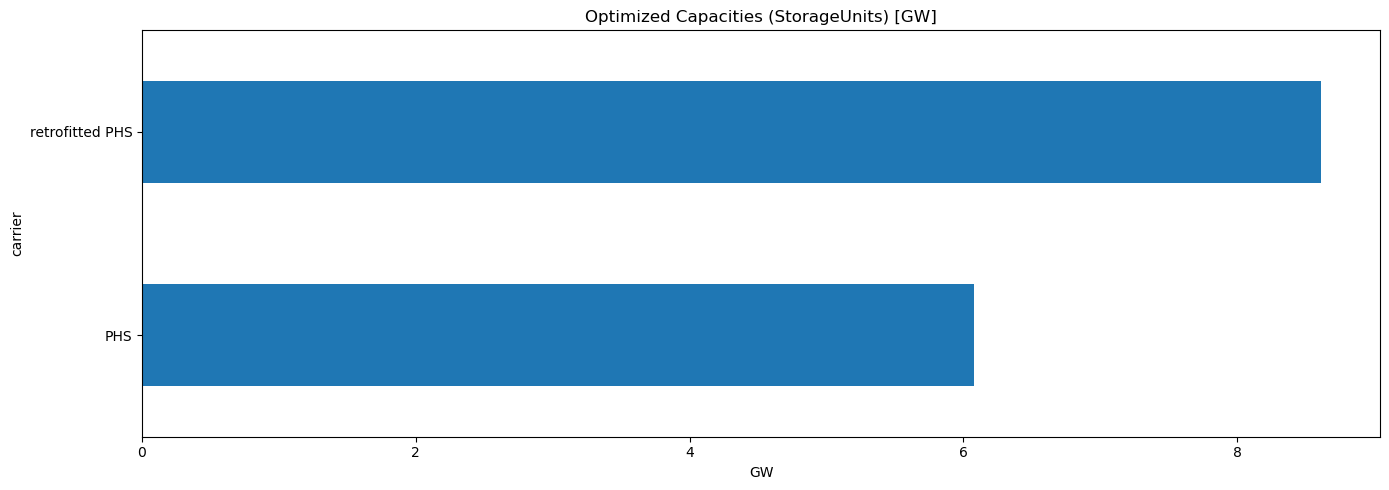

In [ ]:
cap_by_carrier = su.groupby("carrier")[["p_nom_opt"]].sum() / 1e3  # GW
cap_by_carrier = cap_by_carrier[cap_by_carrier["p_nom_opt"] > 0]
cap_by_carrier.sort_values("p_nom_opt").plot.barh(
    legend=False, title="Optimized Capacities (StorageUnits) [GW]"
)
plt.xlabel("GW")
plt.tight_layout()
plt.show()

## 5  Dispatch – Retrofitted PHS vs. Hydro
Dispatch and storage profiles of the storage units.

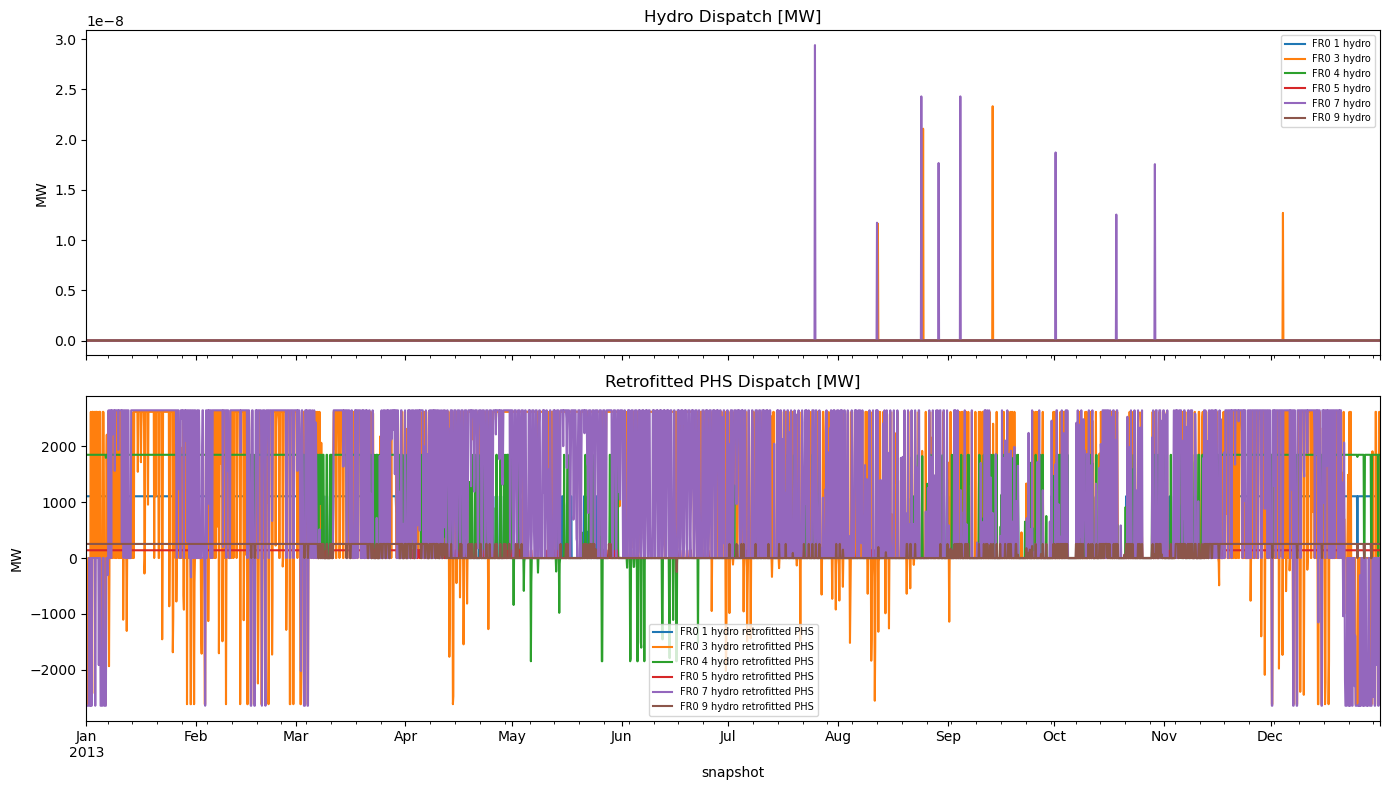

In [ ]:
# Dispatch (p) – positive = generation, negative = pumping (for PHS)
p = n.storage_units_t.p

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Hydro dispatch
if not hydro.empty:
    p[hydro.index].plot(ax=axes[0], title="Hydro Dispatch [MW]")
    axes[0].set_ylabel("MW")
    axes[0].legend(fontsize=7)

# Retrofit PHS dispatch
if not retrofit.empty:
    p[retrofit.index].plot(ax=axes[1], title="Retrofitted PHS Dispatch [MW]")
    axes[1].set_ylabel("MW")
    axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 6  State of Charge – Retrofitted PHS
Shows whether the PHS units actually operate as pumped storage (charging + discharging).

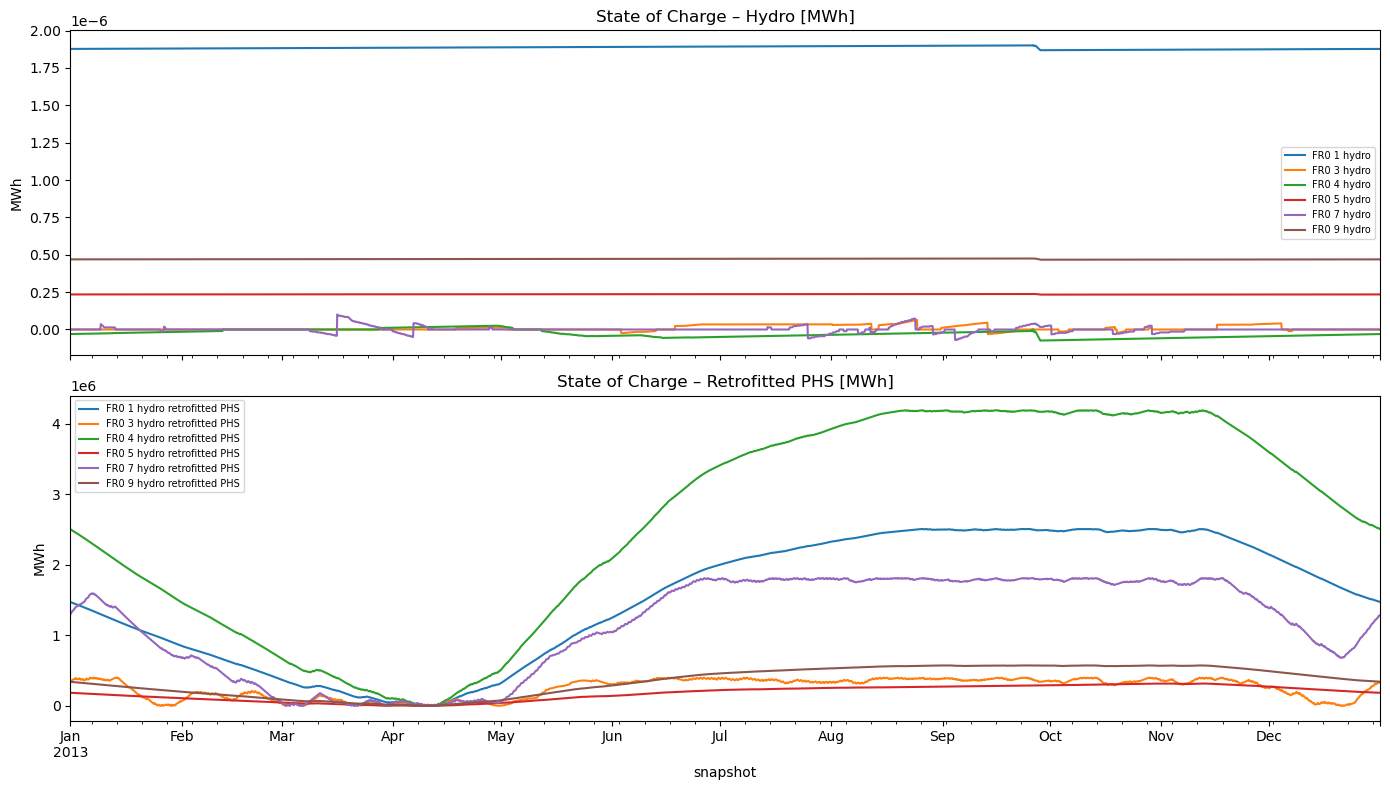

In [ ]:
soc = n.storage_units_t.state_of_charge

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

if not hydro.empty and any(c in soc.columns for c in hydro.index):
    hydro_soc_cols = [c for c in hydro.index if c in soc.columns]
    soc[hydro_soc_cols].plot(ax=axes[0], title="State of Charge – Hydro [MWh]")
    axes[0].set_ylabel("MWh")
    axes[0].legend(fontsize=7)

if not retrofit.empty and any(c in soc.columns for c in retrofit.index):
    retrofit_soc_cols = [c for c in retrofit.index if c in soc.columns]
    soc[retrofit_soc_cols].plot(ax=axes[1], title="State of Charge – Retrofitted PHS [MWh]")
    axes[1].set_ylabel("MWh")
    axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 7  System Dispatch by Carrier
Stacked area chart of all generation sources.

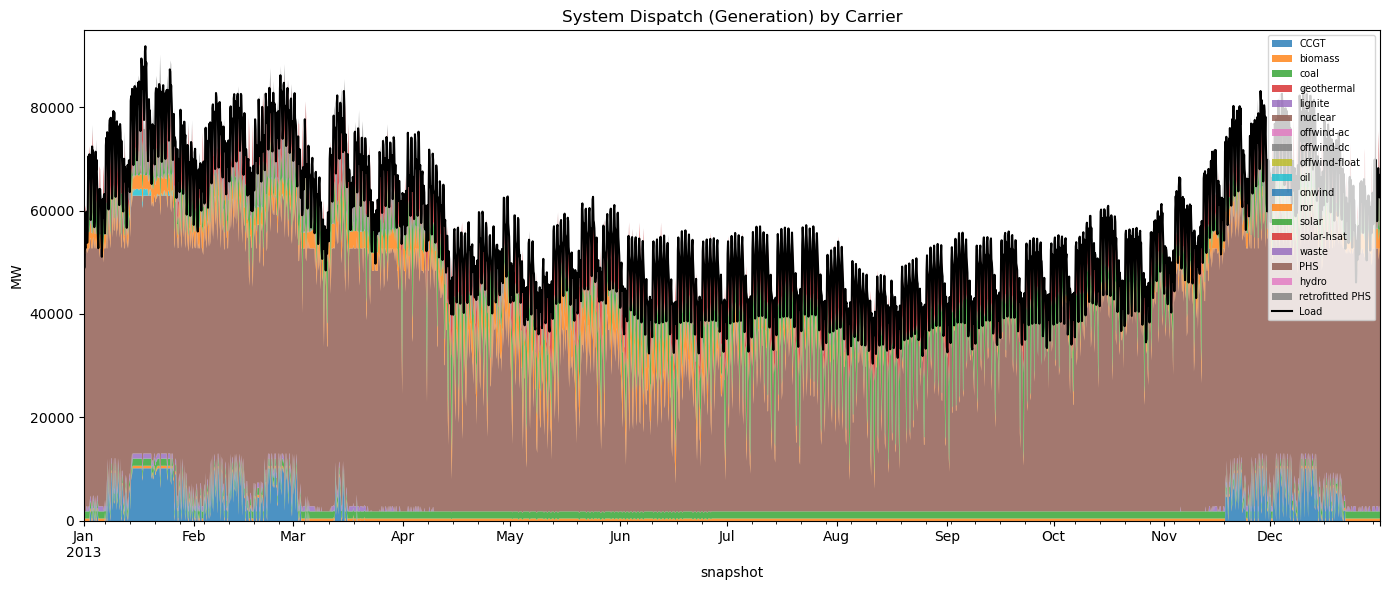

In [ ]:
# Aggregate generators + storage units by carrier
gen_dispatch = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
su_dispatch = n.storage_units_t.p.T.groupby(n.storage_units.carrier).sum().T

total_dispatch = pd.concat([gen_dispatch, su_dispatch], axis=1)
# Only positive values (generation)
total_dispatch_pos = total_dispatch.clip(lower=0)

fig, ax = plt.subplots(figsize=(14, 6))
total_dispatch_pos.plot.area(ax=ax, linewidth=0, alpha=0.8)

# Overlay load
load = n.loads_t.p_set.sum(axis=1)
load.plot(ax=ax, color="black", linewidth=1.5, label="Load")

ax.set_title("System Dispatch (Generation) by Carrier")
ax.set_ylabel("MW")
ax.legend(loc="upper right", fontsize=7)
plt.tight_layout()
plt.show()

## 8  Cost Breakdown
Total system costs broken down by carrier.

Capital costs by carrier [M€/a]:


,Capital Cost [M€/a]
carrier,
nuclear,62258.29
ror,2788.56
PHS,1409.56
CCGT,1291.21
retrofitted PHS,1033.61
solar,977.50
solar-hsat,807.46
coal,587.22
lignite,414.23


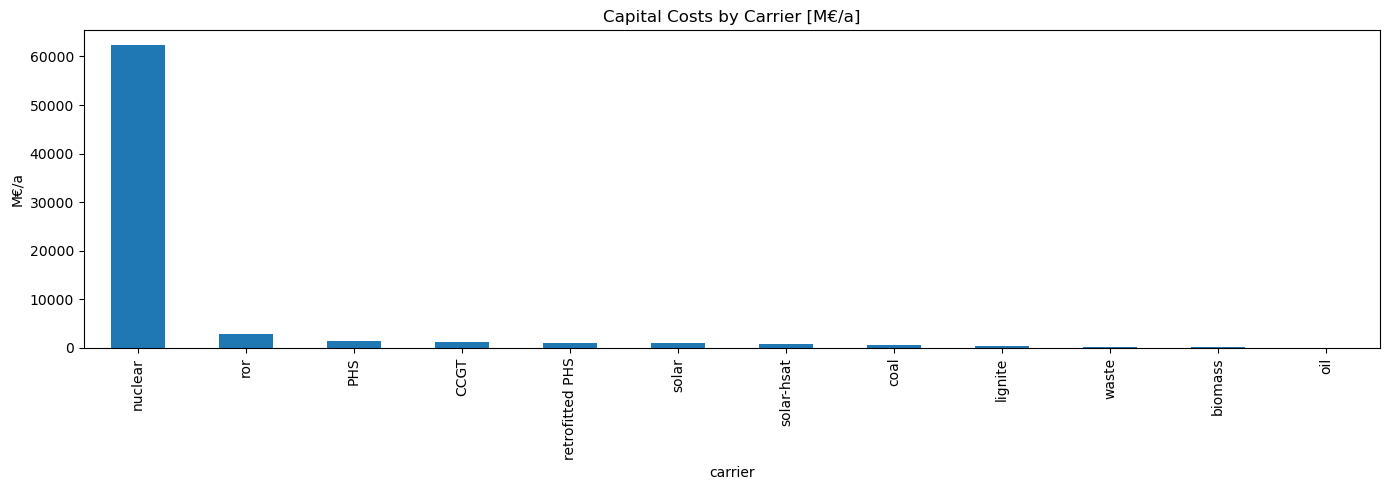


Retrofit capital cost total: 1033.61 M€/a
System total cost (objective): 11053.53 M€


In [ ]:
# Capital cost contributions
su_cap_cost = (su["p_nom_opt"] * su["capital_cost"]).groupby(su["carrier"]).sum()
gen_cap_cost = (n.generators["p_nom_opt"] * n.generators["capital_cost"]).groupby(n.generators["carrier"]).sum()

all_cap = pd.concat([gen_cap_cost, su_cap_cost]).sort_values(ascending=False)
all_cap = all_cap[all_cap > 0] / 1e6  # M€

print("Capital costs by carrier [M€/a]:")
display(all_cap.to_frame("Capital Cost [M€/a]").round(2))

all_cap.plot.bar(title="Capital Costs by Carrier [M€/a]")
plt.ylabel("M€/a")
plt.tight_layout()
plt.show()

print(f"\nRetrofit capital cost total: {su_cap_cost.get('retrofitted PHS', 0)/1e6:.2f} M€/a")
print(f"System total cost (objective): {n.objective/1e6:.2f} M€")

## 9  PHS – Pump Cycle Analysis
Checks whether the retrofitted PHS actually operates bidirectionally (negative p = pumping).

In [ ]:
if not retrofit.empty:
    retrofit_p = n.storage_units_t.p[retrofit.index]

    stats = pd.DataFrame({
        "Max Generation [MW]": retrofit_p.max(),
        "Max Pumping [MW]": retrofit_p.min(),  # negative = pumping
        "Hours Generating": (retrofit_p > 0.1).sum(),
        "Hours Pumping": (retrofit_p < -0.1).sum(),
        "Hours Idle": ((retrofit_p >= -0.1) & (retrofit_p <= 0.1)).sum(),
        "Energy Generated [GWh]": retrofit_p.clip(lower=0).sum() / 1e3,
        "Energy Pumped [GWh]": retrofit_p.clip(upper=0).sum() / 1e3,
    })
    display(stats.round(2))
    
    if (stats["Hours Pumping"] > 0).any():
        print("\n✅ PHS units are actually pumping – retrofit works bidirectionally!")
    else:
        print("\n⚠️ No pumping hours – PHS is only used for generation (like regular hydro).")
else:
    print("No retrofit units present.")

,Max Generation [MW],Max Pumping [MW],Hours Generating,Hours Pumping,Hours Idle,Energy Generated [GWh],Energy Pumped [GWh]
name,,,,,,,
FR0 1 hydro retrofitted PHS,1106.51,0.00,1346,0,1574,1441.73,0.00
FR0 3 hydro retrofitted PHS,2619.10,-2619.10,1523,176,1221,3622.60,-280.04
FR0 4 hydro retrofitted PHS,1849.61,-1849.61,1369,30,1521,2435.30,-33.79
FR0 5 hydro retrofitted PHS,139.00,0.00,1310,0,1610,181.11,0.00
FR0 7 hydro retrofitted PHS,2646.95,-2646.95,1645,99,1176,3626.59,-236.98
FR0 9 hydro retrofitted PHS,252.28,-252.28,1322,2,1596,328.91,-0.26



✅ PHS units are actually pumping – retrofit works bidirectionally!


---
# Natural Inflow & Hourly Operation Analysis

## 10  Natural Inflow Profiles per Bus
Checks whether each bus has a **unique** inflow time series or whether pypsa-eur uses
averaged / identical profiles across buses.  
pypsa-eur distributes a single country-level inflow proportional to `p_nom`, so profiles
have the **same shape** but different magnitudes.

In [ ]:
inflow = n.storage_units_t.inflow

# Check all carriers that might have inflow
carriers_with_inflow = ["hydro", "retrofitted PHS", "PHS"]
for carrier in carriers_with_inflow:
    units = su.query('carrier == @carrier').index
    inflow_cols = [c for c in units if c in inflow.columns and inflow[c].abs().sum() > 0]
    if not inflow_cols:
        print(f"'{carrier}': no inflow time series found.")
        continue
    
    print(f"\n{'='*60}")
    print(f"Carrier: {carrier}  ({len(inflow_cols)} units with inflow)")
    print(f"{'='*60}")
    
    inflow_sub = inflow[inflow_cols]
    
    # Check uniqueness via pairwise correlation
    if len(inflow_cols) > 1:
        corr = inflow_sub.corr()
        off_diag = corr.where(~np.eye(len(corr), dtype=bool))
        mean_corr = off_diag.mean().mean()
        all_identical = np.allclose(
            off_diag.values[~np.isnan(off_diag.values)], 1.0, atol=1e-6
        )
        print(f"Mean pairwise correlation: {mean_corr:.4f}")
        if all_identical:
            print("⚠️  All inflow profiles are IDENTICAL in shape (correlation ≈ 1.0)")
            print("   → pypsa-eur distributes a single country-level inflow by p_nom shares.")
            print("   → Profiles differ only in magnitude, not shape.")
        else:
            print("✅ Inflow profiles differ across buses.")
    else:
        print("Only 1 unit – cannot compare.")
    
    # Basic stats table
    inflow_stats = pd.DataFrame({
        "Bus": su.loc[inflow_cols, "bus"].values,
        "Mean Inflow [MW]": inflow_sub.mean().values,
        "Max Inflow [MW]": inflow_sub.max().values,
        "Total Inflow [GWh]": (inflow_sub.sum() / 1e3).values,
    }, index=inflow_cols)
    display(inflow_stats.round(2))


Carrier: hydro  (6 units with inflow)
Mean pairwise correlation: 1.0000
⚠️  All inflow profiles are IDENTICAL in shape (correlation ≈ 1.0)
   → pypsa-eur distributes a single country-level inflow by p_nom shares.
   → Profiles differ only in magnitude, not shape.


,Bus,Mean Inflow [MW],Max Inflow [MW],Total Inflow [GWh]
FR0 1 hydro,FR0 1,570.13,1552.82,1664.77
FR0 3 hydro,FR0 3,1349.48,3675.52,3940.50
FR0 4 hydro,FR0 4,953.01,2595.65,2782.78
FR0 5 hydro,FR0 5,71.62,195.07,209.13
FR0 7 hydro,FR0 7,1363.83,3714.60,3982.39
FR0 9 hydro,FR0 9,129.99,354.04,379.56



Carrier: retrofitted PHS  (6 units with inflow)
Mean pairwise correlation: 1.0000
⚠️  All inflow profiles are IDENTICAL in shape (correlation ≈ 1.0)
   → pypsa-eur distributes a single country-level inflow by p_nom shares.
   → Profiles differ only in magnitude, not shape.


,Bus,Mean Inflow [MW],Max Inflow [MW],Total Inflow [GWh]
FR0 1 hydro retrofitted PHS,FR0 1,570.13,1552.82,1664.77
FR0 3 hydro retrofitted PHS,FR0 3,1349.48,3675.52,3940.50
FR0 4 hydro retrofitted PHS,FR0 4,953.01,2595.65,2782.78
FR0 5 hydro retrofitted PHS,FR0 5,71.62,195.07,209.13
FR0 7 hydro retrofitted PHS,FR0 7,1363.83,3714.60,3982.39
FR0 9 hydro retrofitted PHS,FR0 9,129.99,354.04,379.56


'PHS': no inflow time series found.


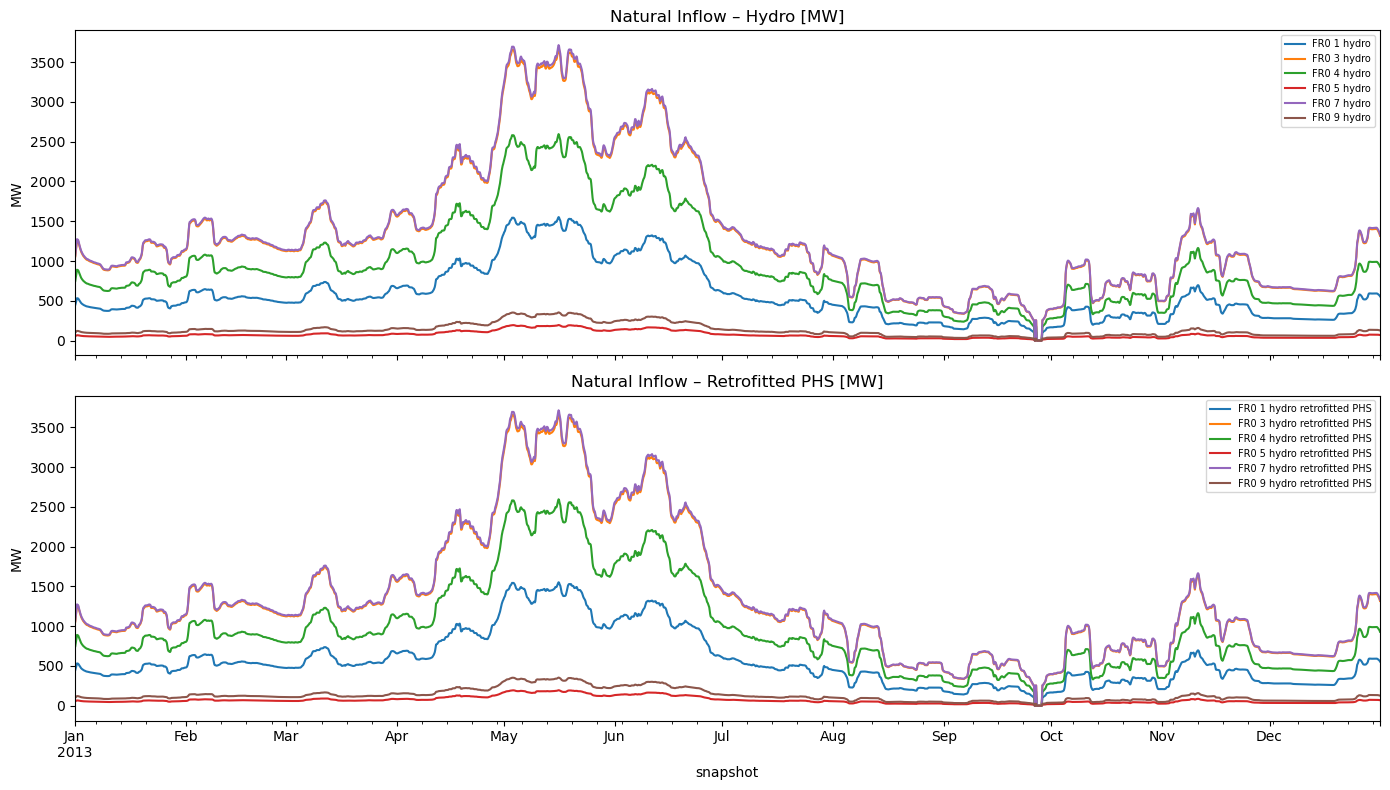


Hydro ↔ Retrofit inflow comparison (should be identical):
  FR0 1 hydro vs FR0 1 hydro retrofitted PHS: ✅ identical
  FR0 3 hydro vs FR0 3 hydro retrofitted PHS: ✅ identical
  FR0 4 hydro vs FR0 4 hydro retrofitted PHS: ✅ identical
  FR0 5 hydro vs FR0 5 hydro retrofitted PHS: ✅ identical
  FR0 7 hydro vs FR0 7 hydro retrofitted PHS: ✅ identical
  FR0 9 hydro vs FR0 9 hydro retrofitted PHS: ✅ identical


In [ ]:
# Plot raw inflow time series for hydro and retrofitted PHS
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

hydro_inflow_cols = [c for c in hydro.index if c in inflow.columns and inflow[c].abs().sum() > 0]
retro_inflow_cols = [c for c in retrofit.index if c in inflow.columns and inflow[c].abs().sum() > 0]

if hydro_inflow_cols:
    inflow[hydro_inflow_cols].plot(ax=axes[0], title='Natural Inflow – Hydro [MW]')
    axes[0].set_ylabel('MW')
    axes[0].legend(fontsize=7)
else:
    axes[0].set_title('No inflow data for hydro units')

if retro_inflow_cols:
    inflow[retro_inflow_cols].plot(ax=axes[1], title='Natural Inflow – Retrofitted PHS [MW]')
    axes[1].set_ylabel('MW')
    axes[1].legend(fontsize=7)
else:
    axes[1].set_title('No inflow data for retrofitted PHS units')

plt.tight_layout()
plt.show()

# Verify that hydro and its corresponding retrofit unit have identical inflow
if hydro_inflow_cols and retro_inflow_cols:
    print("\nHydro ↔ Retrofit inflow comparison (should be identical):")
    for h, r in zip(hydro_inflow_cols, retro_inflow_cols):
        match = np.allclose(inflow[h].values, inflow[r].values, atol=1e-6)
        print(f"  {h} vs {r}: {'✅ identical' if match else '❌ DIFFERENT'}")

## 11  Inflow Shape Check – Scaled Country Average or Unique?
pypsa-eur distributes the country-level hydro inflow to individual buses proportional to
`p_nom`. This means profiles have the **same shape** but different magnitudes.  
Here we normalise each profile to [0,1] and overlay them to visually confirm.

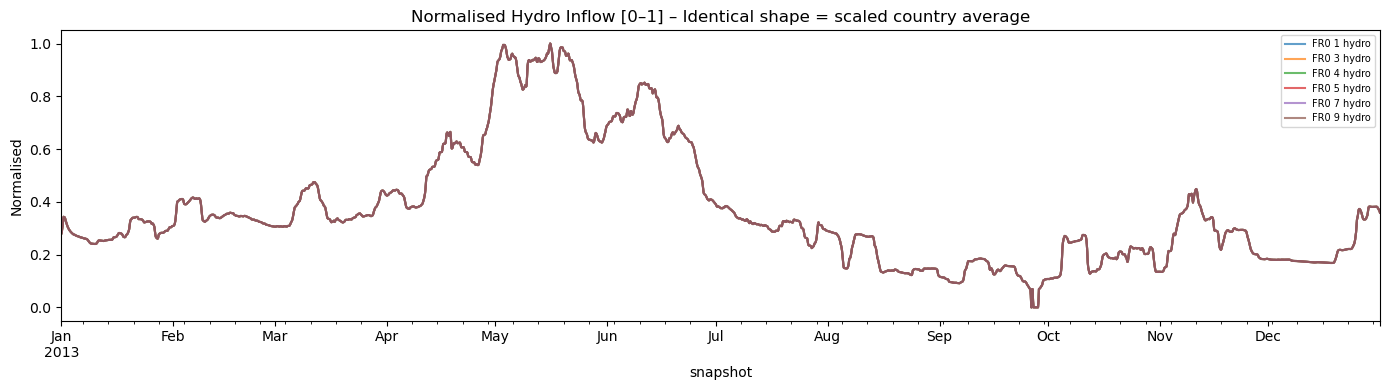

Max deviation FR0 3 hydro vs FR0 1 hydro: 6.66e-16  → IDENTICAL shape
Max deviation FR0 4 hydro vs FR0 1 hydro: 4.44e-16  → IDENTICAL shape
Max deviation FR0 5 hydro vs FR0 1 hydro: 4.77e-15  → IDENTICAL shape
Max deviation FR0 7 hydro vs FR0 1 hydro: 6.66e-16  → IDENTICAL shape
Max deviation FR0 9 hydro vs FR0 1 hydro: 2.44e-15  → IDENTICAL shape


In [ ]:
if hydro_inflow_cols and len(hydro_inflow_cols) > 1:
    normalised = inflow[hydro_inflow_cols].apply(
        lambda s: (s - s.min()) / (s.max() - s.min() + 1e-12)
    )
    fig, ax = plt.subplots(figsize=(14, 4))
    normalised.plot(ax=ax, alpha=0.7)
    ax.set_title('Normalised Hydro Inflow [0–1] – Identical shape = scaled country average')
    ax.set_ylabel('Normalised')
    ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()
    
    # Quantitative check
    ref = normalised.iloc[:, 0]
    for col in normalised.columns[1:]:
        diff = (normalised[col] - ref).abs().max()
        print(f"Max deviation {col} vs {normalised.columns[0]}: {diff:.2e}"
              f"  → {'IDENTICAL shape' if diff < 1e-6 else 'DIFFERENT shape'}")
else:
    print('Only 1 hydro unit (or no inflow) – nothing to compare.')

## 12  Hourly Dispatch Deep-Dive per Bus
For each bus that has hydro: plots **hydro dispatch**, **retrofitted PHS dispatch** (with
pumping), **inflow**, and **state of charge** on a single figure.

This shows the full operational picture at each location and reveals whether each bus
operates independently with its own inflow/dispatch or shares averaged behaviour.

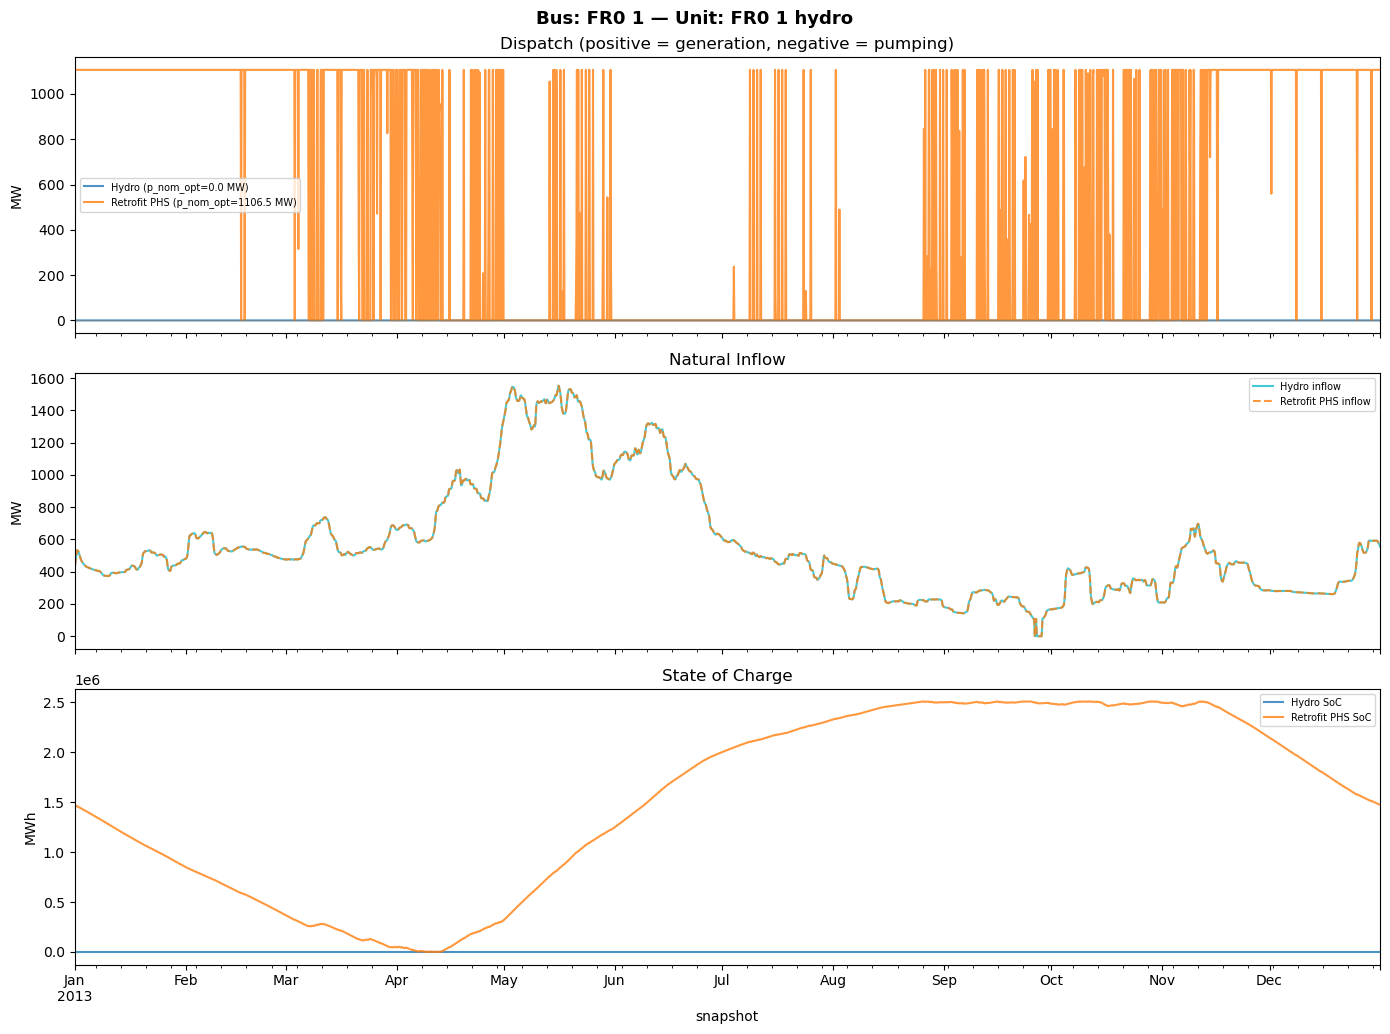

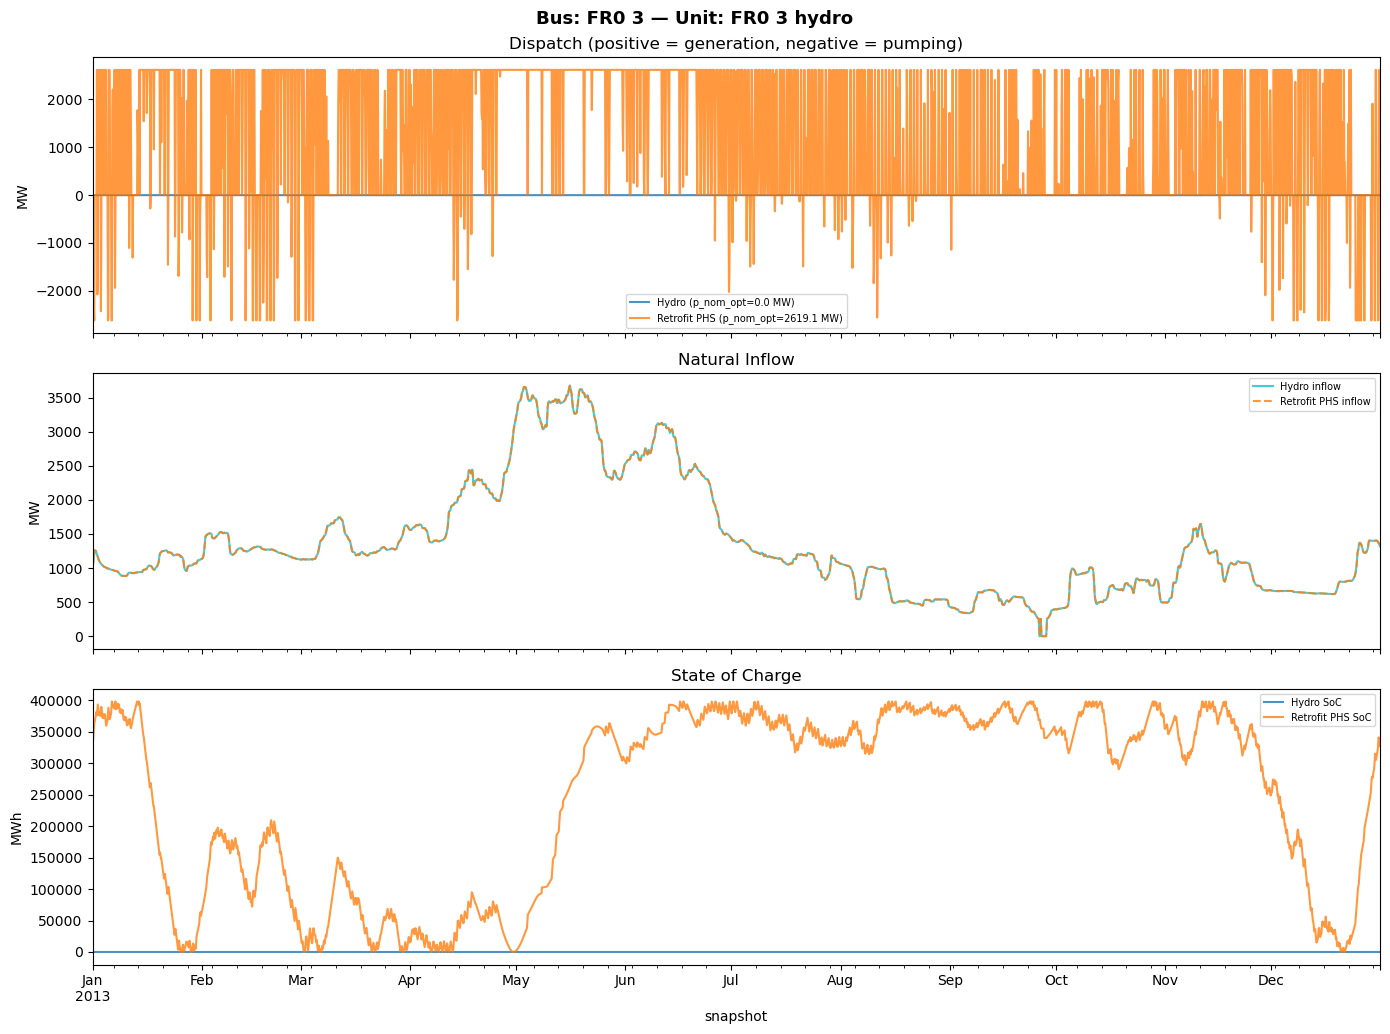

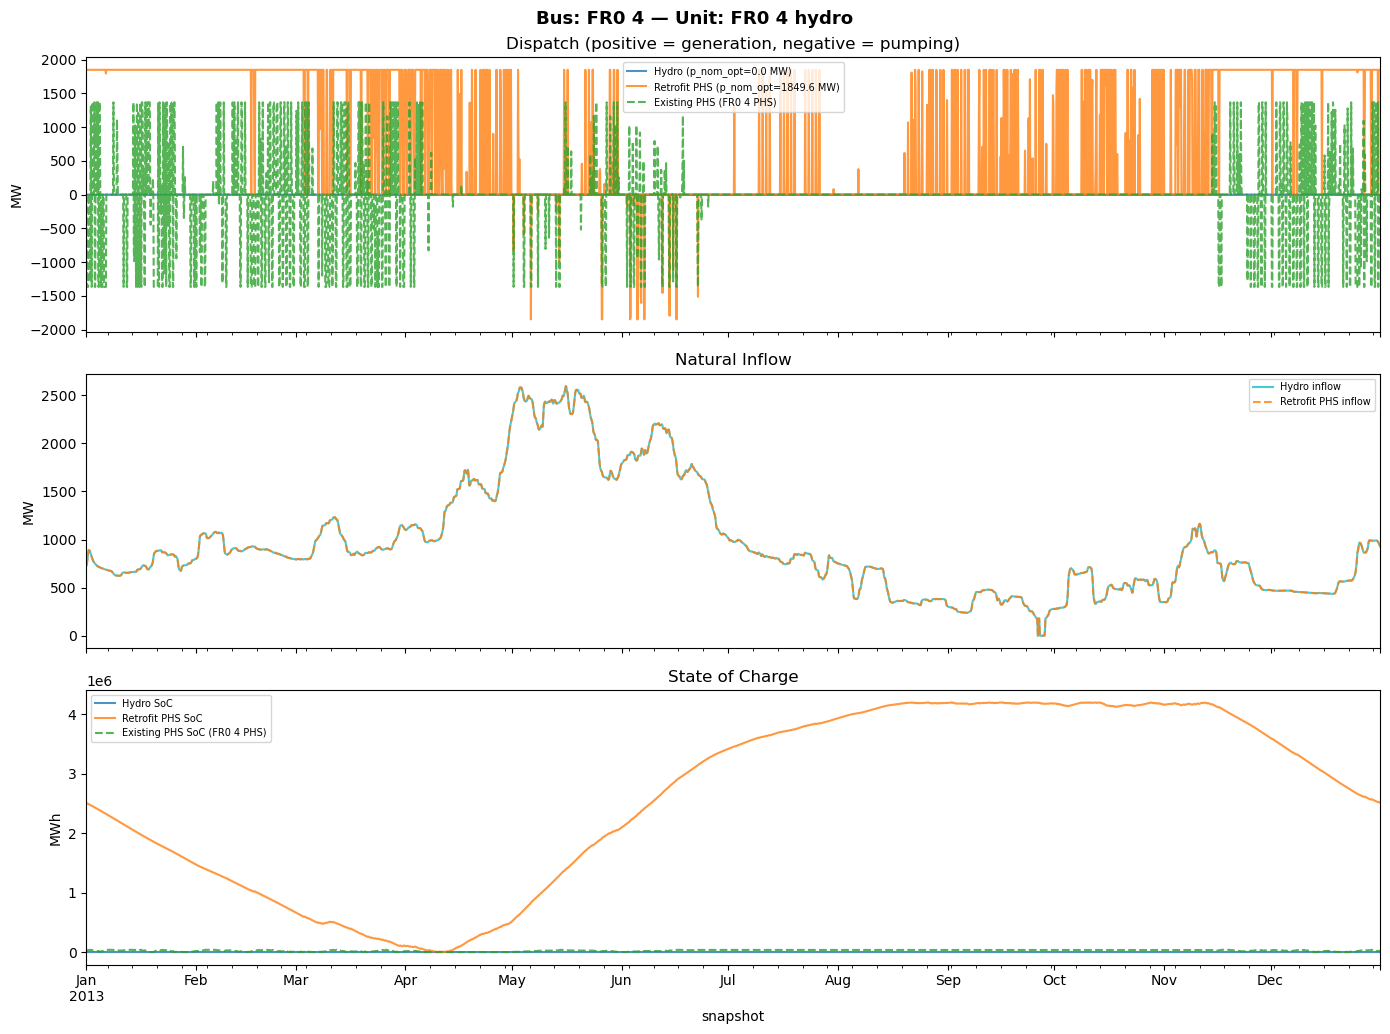

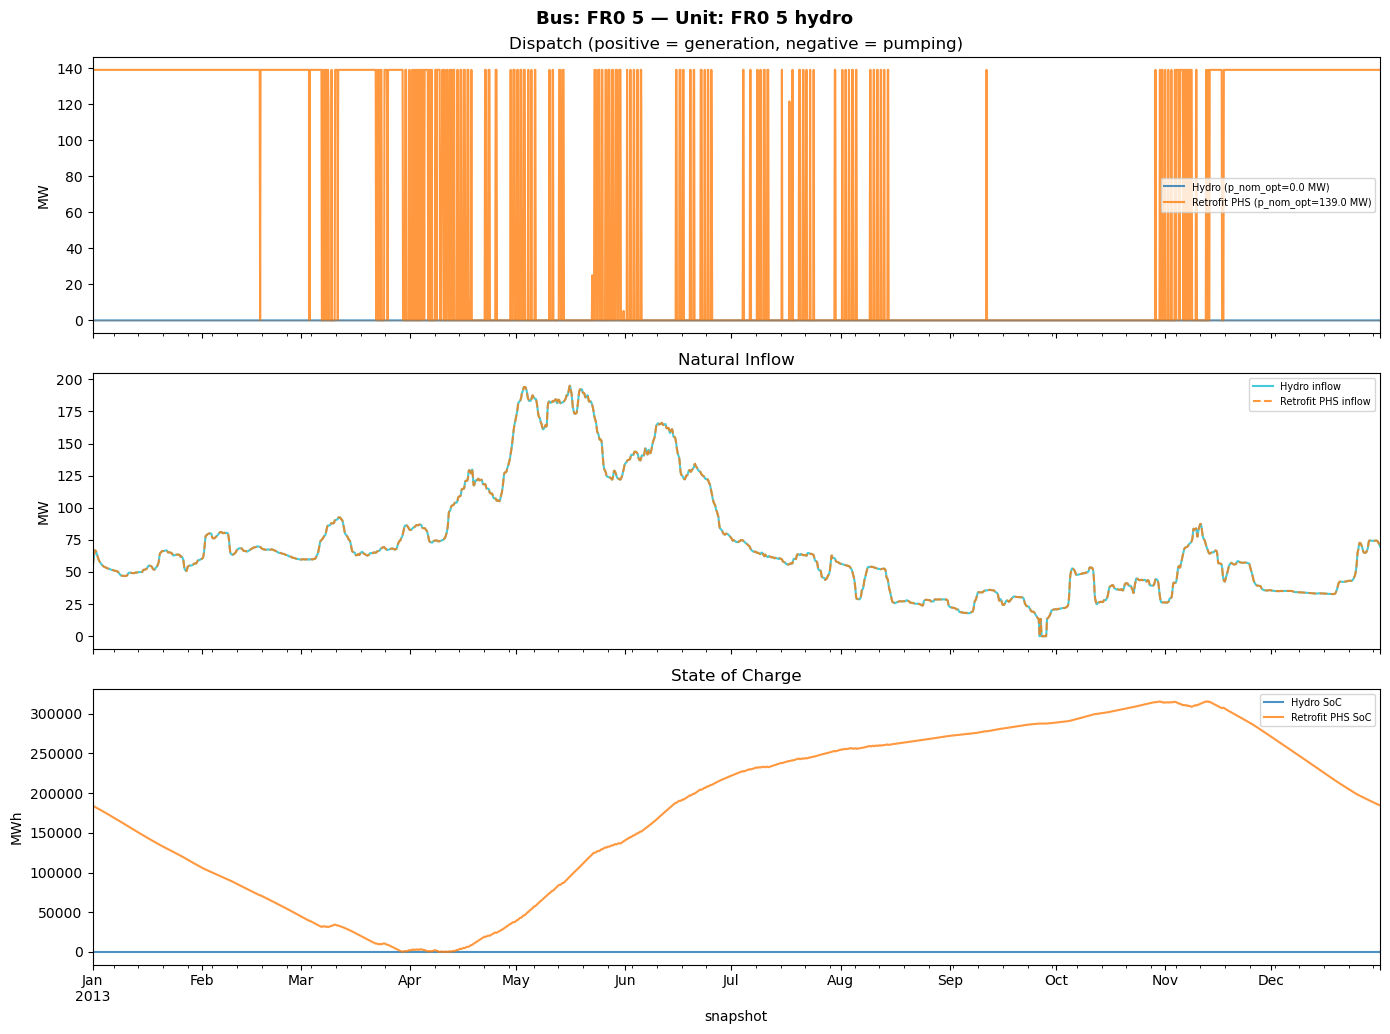

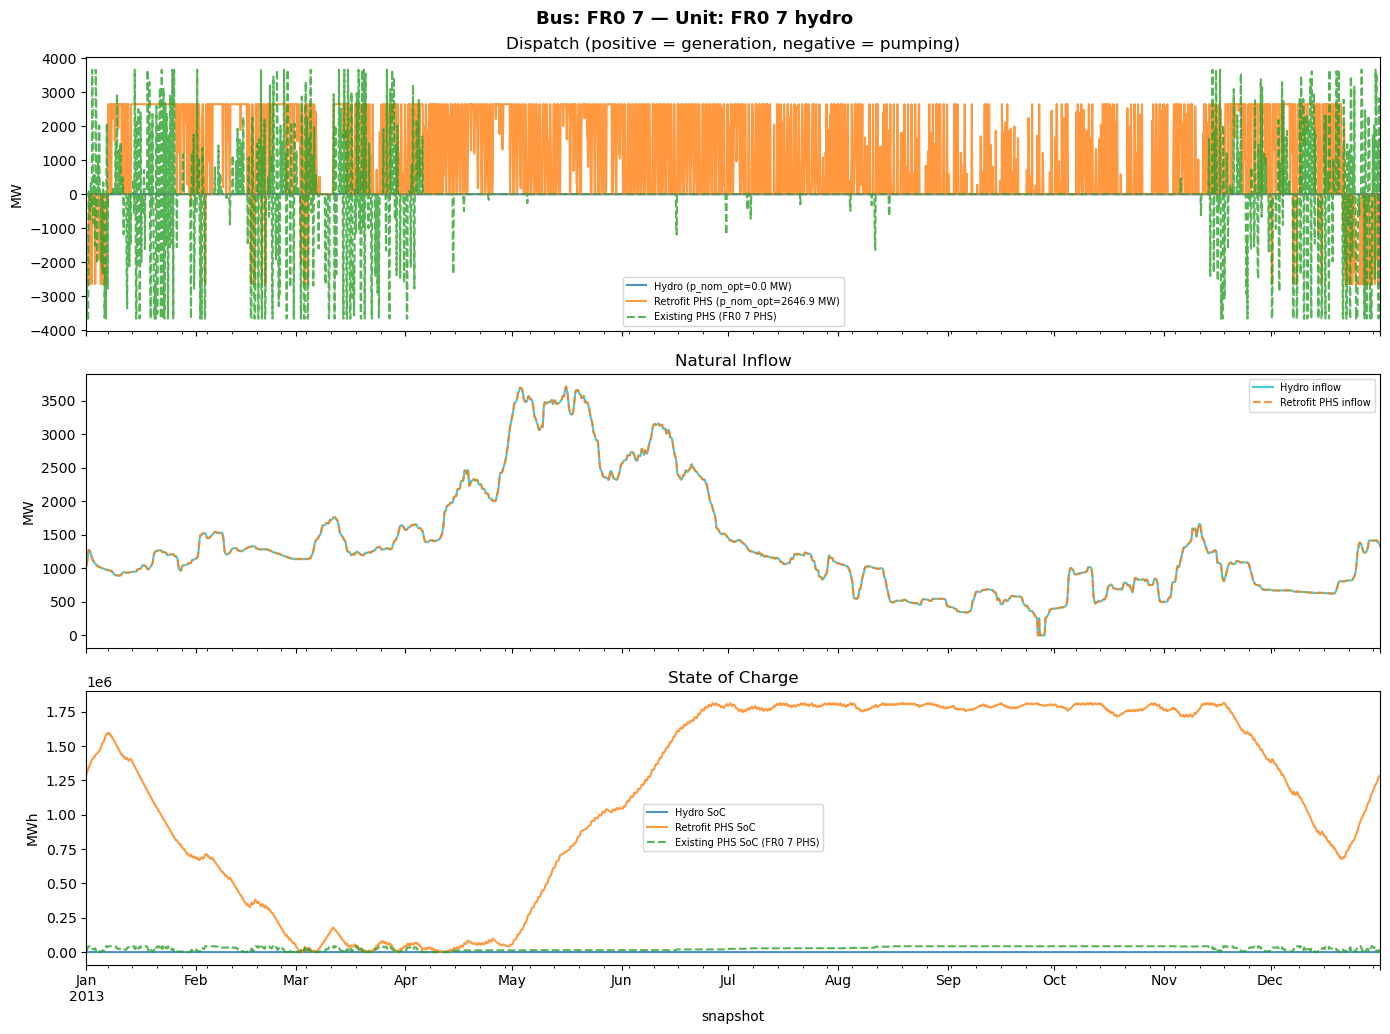

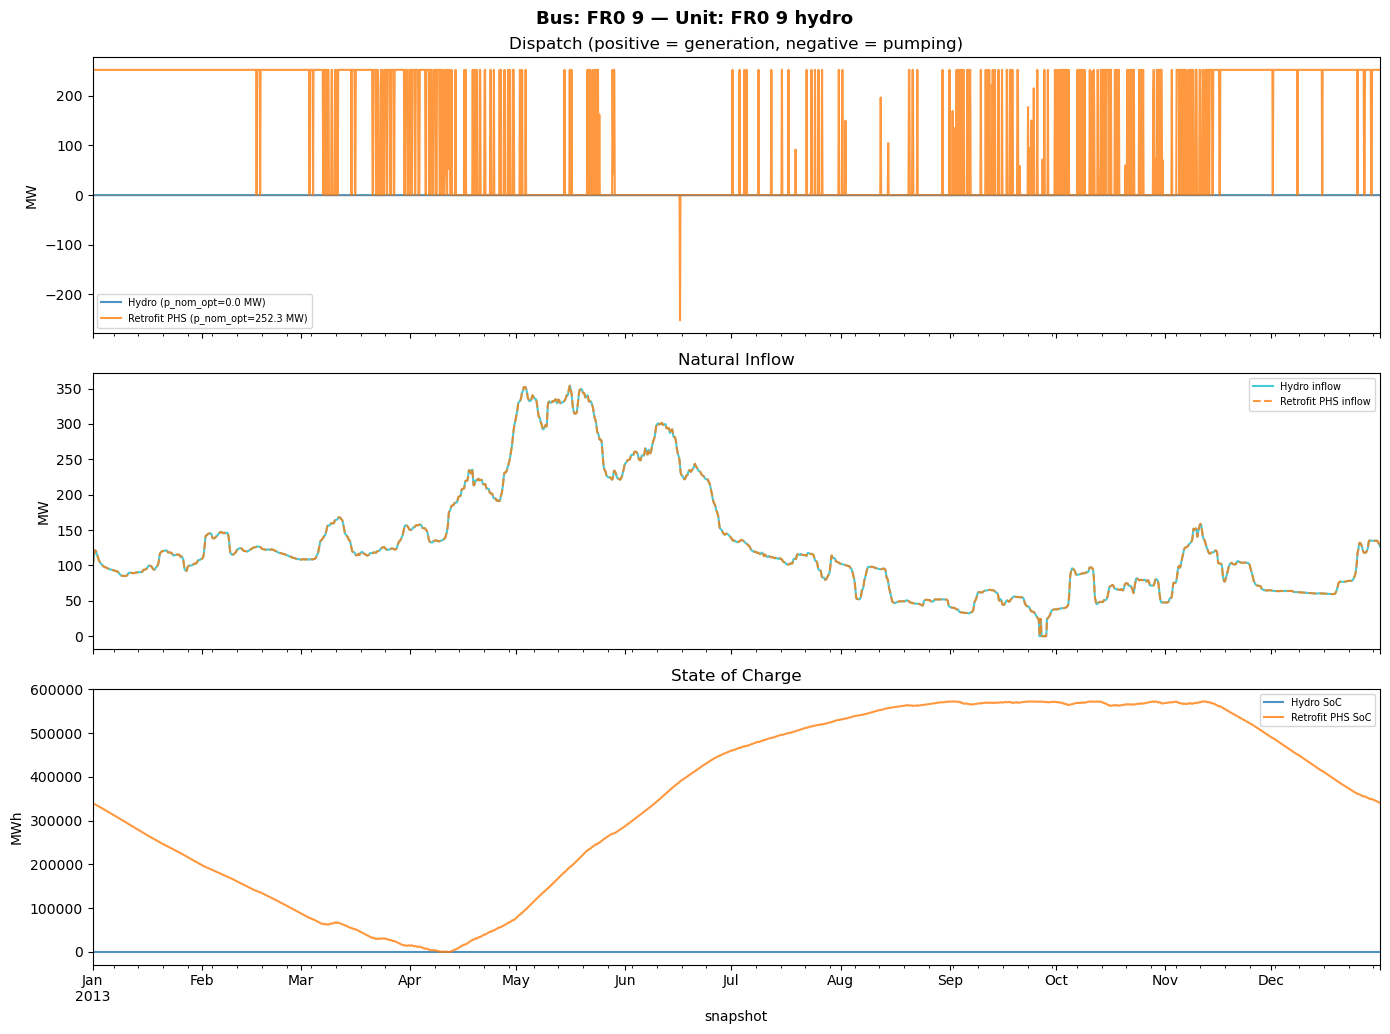

In [ ]:
p = n.storage_units_t.p
soc = n.storage_units_t.state_of_charge

# Existing PHS units (not retrofitted)
phs = su.query('carrier == "PHS"')

for h_name in hydro.index:
    bus = hydro.loc[h_name, 'bus']
    r_name = h_name + ' retrofitted PHS'
    has_retrofit = r_name in retrofit.index
    
    # Find existing PHS on the same bus
    phs_on_bus = phs[phs['bus'] == bus]
    
    n_rows = 3
    fig, axes = plt.subplots(n_rows, 1, figsize=(14, 3.5 * n_rows), sharex=True)
    fig.suptitle(f'Bus: {bus} — Unit: {h_name}', fontsize=13, fontweight='bold')
    
    # Row 1: Dispatch
    ax = axes[0]
    if h_name in p.columns:
        p[h_name].plot(ax=ax, label=f'Hydro (p_nom_opt={hydro.loc[h_name, "p_nom_opt"]:.1f} MW)', alpha=0.8)
    if has_retrofit and r_name in p.columns:
        p[r_name].plot(ax=ax, label=f'Retrofit PHS (p_nom_opt={retrofit.loc[r_name, "p_nom_opt"]:.1f} MW)', alpha=0.8)
    for phs_name in phs_on_bus.index:
        if phs_name in p.columns:
            p[phs_name].plot(ax=ax, label=f'Existing PHS ({phs_name})', alpha=0.8, linestyle='--')
    ax.axhline(0, color='grey', linewidth=0.5, linestyle='-')
    ax.set_ylabel('MW')
    ax.set_title('Dispatch (positive = generation, negative = pumping)')
    ax.legend(fontsize=7)
    
    # Row 2: Inflow
    ax = axes[1]
    if h_name in inflow.columns:
        inflow[h_name].plot(ax=ax, label='Hydro inflow', color='tab:cyan', alpha=0.8)
    if has_retrofit and r_name in inflow.columns:
        inflow[r_name].plot(ax=ax, label='Retrofit PHS inflow', color='tab:orange', linestyle='--', alpha=0.8)
    ax.set_ylabel('MW')
    ax.set_title('Natural Inflow')
    ax.legend(fontsize=7)
    
    # Row 3: State of Charge
    ax = axes[2]
    if h_name in soc.columns:
        soc[h_name].plot(ax=ax, label='Hydro SoC', alpha=0.8)
    if has_retrofit and r_name in soc.columns:
        soc[r_name].plot(ax=ax, label='Retrofit PHS SoC', alpha=0.8)
    for phs_name in phs_on_bus.index:
        if phs_name in soc.columns:
            soc[phs_name].plot(ax=ax, label=f'Existing PHS SoC ({phs_name})', linestyle='--', alpha=0.8)
    ax.set_ylabel('MWh')
    ax.set_title('State of Charge')
    ax.legend(fontsize=7)
    
    plt.tight_layout()
    plt.show()

## 13  Energy Balance Check per Unit
Verifies the energy balance:  
`total_inflow + total_pumped_in ≈ total_dispatched + round-trip losses + ΔSoC`

For retrofitted units that are actually pumping, the pumped energy should be clearly visible.

In [ ]:
weight = n.snapshot_weightings.generators.iloc[0]  # hours per snapshot
print(f"Snapshot weighting: {weight} h per step\n")

balance_rows = []
for carrier_name, units_df in [("hydro", hydro), ("retrofitted PHS", retrofit)]:
    for name in units_df.index:
        if name not in p.columns:
            continue
        dispatch = p[name]
        total_gen = dispatch.clip(lower=0).sum() * weight       # MWh
        total_pump = (-dispatch.clip(upper=0)).sum() * weight   # MWh (positive value)
        total_inflow_val = inflow[name].sum() * weight if name in inflow.columns else 0
        
        eta_s = units_df.loc[name, 'efficiency_store']
        eta_d = units_df.loc[name, 'efficiency_dispatch']
        
        balance_rows.append({
            "Unit": name,
            "Carrier": carrier_name,
            "p_nom_opt [MW]": units_df.loc[name, 'p_nom_opt'],
            "η_store": eta_s,
            "η_dispatch": eta_d,
            "Inflow [GWh]": total_inflow_val / 1e3,
            "Generated [GWh]": total_gen / 1e3,
            "Pumped In [GWh]": total_pump / 1e3,
            "Net Pumped (after η) [GWh]": (total_pump * eta_s) / 1e3,
        })

balance_df = pd.DataFrame(balance_rows).set_index("Unit")
display(balance_df.round(3))

print("\nNote: Generated energy should come from inflow + net pumped energy (minus round-trip losses).")
print("      If ΔSoC ≈ 0 (cyclic), then: Generated ≈ Inflow * η_dispatch + Pumped * η_store * η_dispatch")

Snapshot weighting: 3.0 h per step



,Carrier,p_nom_opt [MW],η_store,η_dispatch,Inflow [GWh],Generated [GWh],Pumped In [GWh],Net Pumped (after η) [GWh]
Unit,,,,,,,,
FR0 1 hydro,hydro,0.000,0.000,0.900,4994.303,0.000,0.000,0.000
FR0 3 hydro,hydro,0.000,0.000,0.900,11821.486,0.000,0.000,0.000
FR0 4 hydro,hydro,0.000,0.000,0.900,8348.336,0.000,0.000,0.000
FR0 5 hydro,hydro,0.000,0.000,0.900,627.386,0.000,0.000,0.000
FR0 7 hydro,hydro,0.000,0.000,0.900,11947.176,0.000,0.000,0.000
FR0 9 hydro,hydro,0.000,0.000,0.900,1138.683,0.000,0.000,0.000
FR0 1 hydro retrofitted PHS,retrofitted PHS,1106.510,0.866,0.866,4994.303,4325.193,0.000,0.000
FR0 3 hydro retrofitted PHS,retrofitted PHS,2619.102,0.866,0.866,11821.486,10867.788,840.107,727.554
FR0 4 hydro retrofitted PHS,retrofitted PHS,1849.610,0.866,0.866,8348.336,7305.901,101.374,87.793



Note: Generated energy should come from inflow + net pumped energy (minus round-trip losses).
      If ΔSoC ≈ 0 (cyclic), then: Generated ≈ Inflow * η_dispatch + Pumped * η_store * η_dispatch


---
## 14  Summary

In [ ]:
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Hydro units:              {len(hydro)}")
print(f"Retrofit units:           {len(retrofit)}")
print(f"Actually retrofitted:     {n_retrofitted}")
print(f"Capacity conservation:    {'✅ OK' if np.allclose(capacity_sum, original_cap, atol=0.1) else '❌ VIOLATED'}")

if not retrofit.empty:
    total_hydro_cap = hydro['p_nom_opt'].sum()
    total_retrofit_cap = retrofit['p_nom_opt'].sum()
    total_original = hydro['p_nom_max'].sum()
    print(f"\nCapacity hydro (opt):     {total_hydro_cap:,.1f} MW")
    print(f"Capacity retrofit (opt):  {total_retrofit_cap:,.1f} MW")
    print(f"Original hydro capacity:  {total_original:,.1f} MW")
    print(f"\nRetrofit share:           {total_retrofit_cap/total_original*100:.1f}%")

print(f"\nObjective value:          {n.objective/1e6:.2f} M€")

SUMMARY
Hydro units:              6
Retrofit units:           6
Actually retrofitted:     6
Capacity conservation:    ✅ OK

Capacity hydro (opt):     0.0 MW
Capacity retrofit (opt):  8,613.5 MW
Original hydro capacity:  8,613.5 MW

Retrofit share:           100.0%

Objective value:          11053.53 M€
